# Problem statement
### The average cost of an entry level smartphone is 80 dollars with a population standard deviation of 2.5 dollars. However a manufacturing analyst believes the true mean cost is different, so they audited a sample of 36 units and found the aversage production cost to be 82.5 dollars

In [7]:
import numpy as np
from scipy import stats

# 1. Given Data Inputs
mu = 80               # Population Mean
sigma = 2.5           # Population Standard Deviation
n = 36                # Sample Size
sample_mean = 82.5    # Sample Mean
alpha = 0.05          # Significance Level

# 2. Calculate Standard Error and Z-score
standard_error = sigma / np.sqrt(n)
z_score = (sample_mean - mu) / standard_error

# 3. Calculate Two-Tailed Critical Z and P-Value
z_critical = abs(stats.norm.ppf(alpha / 2))
p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))

# 4. Calculate 95% Confidence Interval
margin_of_error = z_critical * standard_error
ci_lower = sample_mean - margin_of_error
ci_upper = sample_mean + margin_of_error

# Print Results to verify
print(f"Calculated Z-score: {z_score:.2f}")
print(f"Critical Z-threshold: ±{z_critical:.2f}")
print(f"Exact P-value: {p_value:.2e}")
print(f"95% Confidence Interval: [{ci_lower:.2f}, {ci_upper:.2f}]")


Calculated Z-score: 6.00
Critical Z-threshold: ±1.96
Exact P-value: 1.97e-09
95% Confidence Interval: [81.68, 83.32]


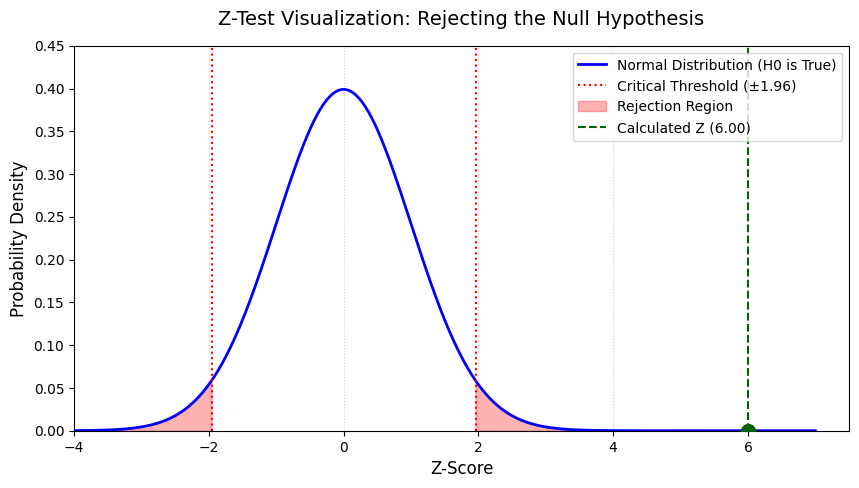

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1. Create a range of Z-scores for the x-axis
x = np.linspace(-4, 7, 1000)
y = norm.pdf(x, 0, 1) # Standard normal distribution curve

# 2. Setup the plot window
plt.figure(figsize=(10, 5))
plt.plot(x, y, color='blue', linewidth=2, label='Normal Distribution (H0 is True)')

# 3. Define and shade critical rejection regions (alpha = 0.05)
z_crit = 1.96
plt.axvline(z_crit, color='red', linestyle=':', label='Critical Threshold (±1.96)')
plt.axvline(-z_crit, color='red', linestyle=':')

# Fill upper tail rejection area
x_upper = np.linspace(z_crit, 4, 200)
plt.fill_between(x_upper, norm.pdf(x_upper, 0, 1), color='red', alpha=0.3, label='Rejection Region')

# Fill lower tail rejection area
x_lower = np.linspace(-4, -z_crit, 200)
plt.fill_between(x_lower, norm.pdf(x_lower, 0, 1), color='red', alpha=0.3)

# 4. Plot the teacher's calculated sample Z-score
z_calculated = 6.00
plt.axvline(z_calculated, color='darkgreen', linestyle='--', linewidth=1.5, label=f'Calculated Z ({z_calculated:.2f})')
plt.scatter([z_calculated], [0], color='darkgreen', s=100, zorder=5) # Visual marker on x-axis

# 5. Add text labels and styling
plt.title('Z-Test Visualization: Rejecting the Null Hypothesis', fontsize=14, pad=15)
plt.xlabel('Z-Score', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.xlim(-4, 7.5) # Extend x-axis boundary to show Z=6 clearly
plt.ylim(0, 0.45)
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.legend(loc='upper right', fontsize=10)

# Display the plot directly in your notebook

plt.show()

